# Data mining \& clustering

The goal if this practical is to adress the folowing problem:
<center style="color:red" >  Given XXX raw, unlabeled documents, ... How to exploit/understand/represent them?</center>

In the previous week, we have seen how to represent textual data with the Bag of Words (BoW) model:
$$X =
	\begin{matrix}
	 & \textbf{t}_j \\
	 & \downarrow \\
	\textbf{d}_i \rightarrow &
	\begin{pmatrix}
	x_{1,1} & \dots & x_{1,d} \\
	\vdots & \ddots & \vdots \\
	x_{N,1} & \dots & x_{N,d} \\
	\end{pmatrix}
	\end{matrix}
	$$

From this BoW representation, we want to answer the following questions:
1. Which clustering algorithm to choose?
    - K-means, LSA, pLSA, LDA
1. What results to expect?
    - Semantics, noise cleaning, etc...
1. Which qualitative and quantitative analyses to understand the groups? [comment]: <> (%1. Comment boucler, itérer pour améliorer la qualité du processus?)


<span style="color:magenta" > In this practical, we use a **labeled dataset** in order to evaluate performances with quantitative and well-defined metrics. </span>


In [2]:
import numpy as np
import matplotlib.pyplot as plt

import codecs
import re
import os.path
import sklearn

from wordcloud import WordCloud

## Data loading



In [3]:
from sklearn.datasets import fetch_20newsgroups
newsgroups_train = fetch_20newsgroups(subset='train')

In [4]:
# conversion BoW + tf-idf
from sklearn.feature_extraction.text import TfidfVectorizer
#vectorizer = TfidfVectorizer()
vectorizer = TfidfVectorizer(max_df=0.95, min_df=2, max_features=1000, stop_words='english')

vectors = vectorizer.fit_transform(newsgroups_train.data)
print(vectors.shape)

vocab = vectorizer.get_feature_names_out()

# sparsity measure = 44 active words over 1000 per document (157 over 130000) !!
print(vectors.nnz / float(vectors.shape[0]))

(11314, 1000)
44.164928407283014


In [5]:
# retrieve words
print([(i,vectorizer.get_feature_names_out()[i]) \
       for i in np.random.randint(vectors.shape[1], size=10)])

[(np.int64(761), 'report'), (np.int64(750), 'received'), (np.int64(366), 'exist'), (np.int64(325), 'distribution'), (np.int64(279), 'cs'), (np.int64(202), 'cc'), (np.int64(334), 'doug'), (np.int64(667), 'outside'), (np.int64(951), 'version'), (np.int64(838), 'sorry')]


In [6]:
# labels (only for evaluation)
Y = newsgroups_train.target
print(Y[:10])
print([newsgroups_train.target_names[i] for i in Y[:20]]) # vraie classe

[ 7  4  4  1 14 16 13  3  2  4]
['rec.autos', 'comp.sys.mac.hardware', 'comp.sys.mac.hardware', 'comp.graphics', 'sci.space', 'talk.politics.guns', 'sci.med', 'comp.sys.ibm.pc.hardware', 'comp.os.ms-windows.misc', 'comp.sys.mac.hardware', 'rec.motorcycles', 'talk.religion.misc', 'comp.sys.mac.hardware', 'sci.space', 'misc.forsale', 'alt.atheism', 'comp.graphics', 'rec.autos', 'sci.electronics', 'comp.windows.x']


# 0) Word clouds
### Drawing word clouds from the raw corpus or words' frequencies :  [make word clouds !](https://github.com/amueller/word_cloud)

### Installation
If you are using pip:

`pip install wordcloud`

### If you are using conda, you can install from the conda-forge channel:

`conda install -c conda-forge wordcloud`

### Let's look at the most frequent words in this dataset

In [7]:
data = np.array(newsgroups_train.data)
corpus = "".join(data)
words = corpus.split() # optional args to choose the splitting chars
print("Nb mots=",len(words))
# Lets find the most frequence words Your code here

Nb mots= 3252437


### Plot the N frequent words and verify that its follows a Zipf law

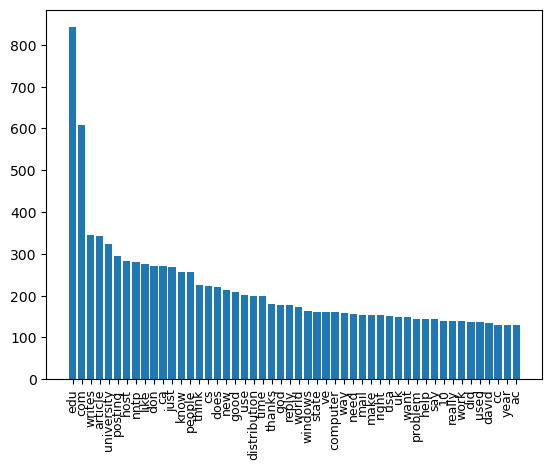

In [8]:
# Your code here

freqs = vectors.sum(0).A1

top_freqs, top_words = zip(*sorted(zip(freqs,vocab), key=lambda x: x[0]))
top_freqs, top_words = map(list,zip(*sorted(zip(freqs,vocab), key=lambda x: x[0], reverse=True)))
plt.bar(x=top_words[:50], height=top_freqs[:50])
plt.xticks(rotation=90, size =9)
plt.show()

### Experiment word clouds

(np.float64(-0.5), np.float64(399.5), np.float64(199.5), np.float64(-0.5))

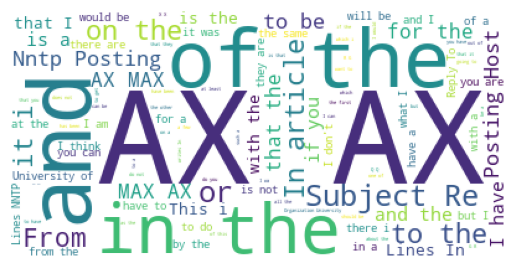

In [9]:
wordcloud = WordCloud(background_color='white', stopwords = [], max_words=100).generate(corpus)

plt.figure()
plt.imshow(wordcloud)
plt.axis('off')

(np.float64(-0.5), np.float64(399.5), np.float64(199.5), np.float64(-0.5))

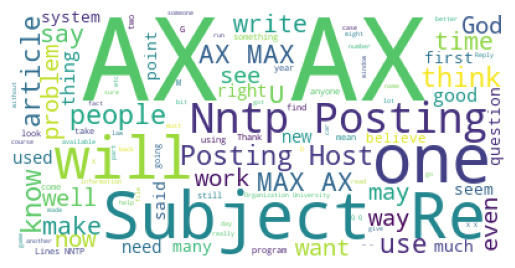

In [10]:
from wordcloud import STOPWORDS # Note: this is the default option
wordcloud = WordCloud(background_color='white', stopwords = STOPWORDS, max_words=100).generate(corpus)

plt.figure()
plt.imshow(wordcloud)
plt.axis("off")

### Use word clouds with generate\_from\_frequencies.
N.B.: retrieve the most words frequencies using a CountVectorizer

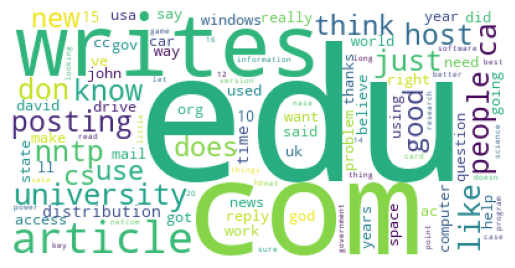

In [11]:
# Your code here

counts = dict(zip(vocab, vectors.sum(0).A1))
wordcloud = WordCloud(background_color='white', stopwords = STOPWORDS, max_words=100).generate_from_frequencies(counts)

plt.figure()
plt.imshow(wordcloud)
plt.axis("off")
plt.show()

### Drawing word clouds from classes


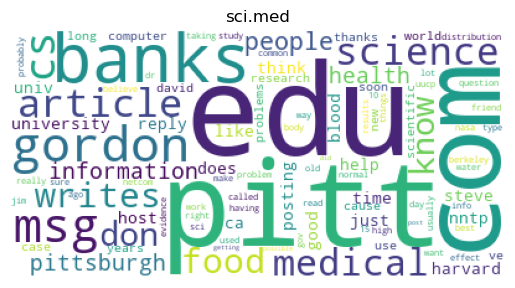

In [12]:
# Your code here
cl = 13
class_mask = Y == cl
counts = dict(zip(vocab, vectors[class_mask].sum(0).A1))
wordcloud = WordCloud(background_color='white', stopwords = STOPWORDS, max_words=100).generate_from_frequencies(counts)

plt.figure()
plt.imshow(wordcloud)
plt.axis("off")
plt.title(f"{newsgroups_train.target_names[cl]}")
plt.show()

# 1) Clustering algorithm: K-Means

**Let's start by the most famous and simple unsupervised algorithm: $k$-means!**
Look at [sklear documentation](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html)
and apply it to your BoW matrix.


In [13]:
from sklearn.cluster import KMeans
# your code here
kmeans = KMeans(n_clusters=20, random_state=0, max_iter=10, n_init=10).fit(vectors)
# Getting clusters:
kmeans.cluster_centers_

array([[2.64200772e-03, 1.72556979e-03, 1.10330745e-03, ...,
        5.70528778e-03, 2.72938417e-03, 2.51514002e-03],
       [3.61169636e-03, 2.67107525e-03, 6.67928714e-04, ...,
        6.99879179e-03, 2.44666453e-03, 3.15483514e-03],
       [3.23407676e-03, 2.17253305e-03, 1.94828380e-03, ...,
        4.44554390e-03, 4.06729375e-03, 8.75936802e-04],
       ...,
       [3.25722139e-03, 1.12336419e-02, 1.51121114e-03, ...,
        1.24136961e-02, 5.32988561e-03, 7.42519147e-03],
       [2.16881195e-03, 2.78943545e-02, 3.96979682e-04, ...,
        7.28880416e-03, 1.25270533e-02, 5.51950356e-03],
       [3.82974480e-03, 2.71791298e-03, 2.51429870e-03, ...,
        5.28086807e-03, 1.83526233e-03, 5.76348639e-05]], shape=(20, 1000))

### Clustering Analysis:
1. **Qualtitative:**
    - Look at the most important words for each cluster
    - Perform cluster assignement to each document, and compute word cloud on the document (raw text or frequencies)
2. **Quantitative:**
    - Compute cluster "purity": $p_j= |y^*_j|$, where $y^*_j$ is the most frequent (GT) label in cluster $C_j$ $\Rightarrow$ $p = \frac{1}{N}\sum\limits_j  p_j$
    - Compute [Rand Score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.rand_score.html) and [Adjusted Rand Score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.adjusted_rand_score.html#sklearn.metrics.adjusted_rand_score)

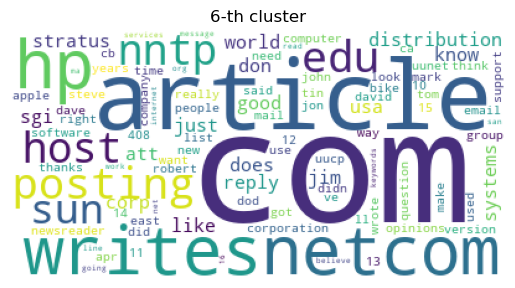

In [14]:
cl = 6
coords = kmeans.cluster_centers_[cl]
wordcloud = WordCloud(background_color='white', stopwords = STOPWORDS, max_words=100).generate_from_frequencies(dict(zip(vocab,coords)))

plt.figure()
plt.imshow(wordcloud)
plt.axis("off")
plt.title(f"{cl}-th cluster")
plt.show()

# TODO: Rand and Adjusted Rand Scores

In [15]:
purity = np.zeros(kmeans.n_clusters)
for cluster in range(kmeans.n_clusters):
    cluster_mask = (kmeans.labels_ == cluster)
    y_counts = np.bincount( Y[cluster_mask])
    gt = np.argmax(y_counts)
    p  = y_counts[gt] / y_counts.sum() # is purity expressed in counts of as probas?
    print(f"Cluster {cluster}, purity={p:1.2}: label {gt} {newsgroups_train.target_names[gt]}")

    purity[cluster] = p

print(f"Overall purity = {purity.sum() / purity.size}")

Cluster 0, purity=0.12: label 9 rec.sport.baseball
Cluster 1, purity=0.1: label 9 rec.sport.baseball
Cluster 2, purity=0.16: label 10 rec.sport.hockey
Cluster 3, purity=0.51: label 2 comp.os.ms-windows.misc
Cluster 4, purity=0.26: label 18 talk.politics.misc
Cluster 5, purity=0.37: label 3 comp.sys.ibm.pc.hardware
Cluster 6, purity=0.14: label 8 rec.motorcycles
Cluster 7, purity=0.12: label 10 rec.sport.hockey
Cluster 8, purity=0.48: label 14 sci.space
Cluster 9, purity=0.15: label 5 comp.windows.x
Cluster 10, purity=0.52: label 7 rec.autos
Cluster 11, purity=0.12: label 6 misc.forsale
Cluster 12, purity=0.62: label 10 rec.sport.hockey
Cluster 13, purity=0.17: label 3 comp.sys.ibm.pc.hardware
Cluster 14, purity=0.68: label 11 sci.crypt
Cluster 15, purity=0.98: label 13 sci.med
Cluster 16, purity=0.61: label 15 soc.religion.christian
Cluster 17, purity=0.23: label 16 talk.politics.guns
Cluster 18, purity=1.0: label 17 talk.politics.mideast
Cluster 19, purity=0.88: label 11 sci.crypt
Ove

# 2) Latent Semantic Analysis (LSA <=> SVD)


**Remember the LSA factorziation**:
$$
\begin{matrix}
 & X  &\!\!\!\!\!=\!\!\!\!\!& U  & \Sigma & V^T \\
  & \textbf{t}_j   &  & \hat{ \textbf{d}_i} & &  \\
 & \downarrow  &  &\downarrow  & & \\
\textbf{d}_i \rightarrow
&
\begin{pmatrix}
x_{1,1} & \dots & x_{1,d} \\
\\
\vdots & \ddots & \vdots \\
\\
x_{N,1} & \dots & x_{N,d} \\
\end{pmatrix}
&
\!\!\!\!\!=\!\!\!\!\!
%&
%(\hat{ \textbf{t}_j}) \rightarrow
&
\begin{pmatrix}
\begin{pmatrix} &  \textbf{u}_1 &  \end{pmatrix} \\
\vdots \\
\begin{pmatrix}  & \textbf{u}_k &  \end{pmatrix}
\end{pmatrix}
%&
%\!\!\!\!\!\cdot\!\!\!\!\!
&
\begin{pmatrix}
\sigma_1 & \dots & 0 \\
\vdots & \ddots & \vdots \\
0 & \dots & \sigma_k \\
\end{pmatrix}
%&
%\!\!\!\!\!\cdot\!\!\!\!\!
&
\begin{pmatrix}
\begin{pmatrix} \, \\ \, \\ \textbf{v}_1 \\ \, \\ \,\end{pmatrix}
\dots
\begin{pmatrix} \, \\ \, \\ \textbf{v}_k \\ \, \\ \, \end{pmatrix}
\end{pmatrix}
\end{matrix}
$$

- Look at [SVD doc in skelarn](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.TruncatedSVD.html#sklearn.decomposition.TruncatedSVD)
- Do the same qualitative/quantitative evaluation than with K-Means
- You can also use LSA as a pre-processing step for K-Means, *i.e.* running K-Means on $\boldsymbol{U}$ matrix above
    - N.B. : try without/with $\ell_2$ normalization of $\boldsymbol{U}$'s rows before running  K-Means
    - You can also benefit from LSA pre-processing for using [t-SNE visualization](https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html) (see code below)


In [16]:
from sklearn.decomposition import TruncatedSVD

svd = TruncatedSVD(n_components=20)
vectors /= np.linalg.norm(vectors.todense(), axis=1).reshape(-1,1)
lsa_vectors = svd.fit_transform(vectors ) # U @ S
# lsa_vectors = lsa_vectors / np.linalg.norm(lsa_vectors, axis=1).reshape(-1,1) # TODO: why normalize rows???
lsa_vocab = "theme-" + np.arange(1, lsa_vectors.shape[1]).astype(str)

In [17]:
kmeans = KMeans(n_clusters=20, random_state=0, max_iter=10, n_init=100).fit(lsa_vectors)
# Getting clusters:
kmeans.cluster_centers_ 

array([[ 2.08743078e-01, -5.72052634e-02,  1.18090553e-01,
         5.10955280e-02, -4.81402858e-03, -6.19623599e-02,
         3.75651938e-02,  7.71830404e-02,  5.35993883e-03,
         3.57503253e-02,  3.70869266e-02, -5.01164788e-02,
         2.55989326e-02,  3.63030579e-01, -1.76306576e-01,
        -1.93658549e-01,  1.68977210e-01,  5.15802267e-02,
        -2.53494002e-02, -1.50872408e-02],
       [ 2.39239098e-01,  1.13785497e-01, -6.84508604e-02,
         5.37117220e-02, -9.29246707e-02, -8.70336445e-03,
        -3.33048864e-03,  2.70537333e-02, -1.03038623e-01,
         3.58540776e-02,  7.65081509e-02,  4.36631090e-02,
        -7.48080827e-02,  1.11322884e-01, -4.84979479e-02,
         1.33432373e-01, -9.27746242e-02,  6.21665337e-02,
         1.22965578e-01, -1.14150476e-01],
       [ 2.46543938e-01, -3.65085956e-02,  7.56927536e-03,
         1.91619107e-02,  4.61622908e-02,  9.16922618e-03,
        -4.90678295e-02, -2.80493283e-03, -5.23065847e-02,
        -6.42533300e-02, -6.4

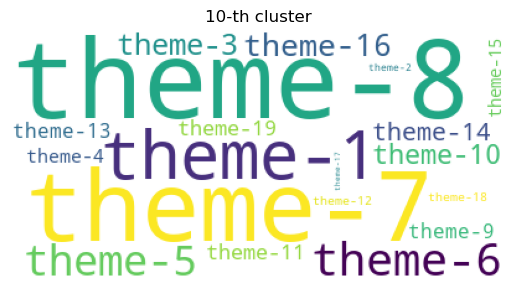

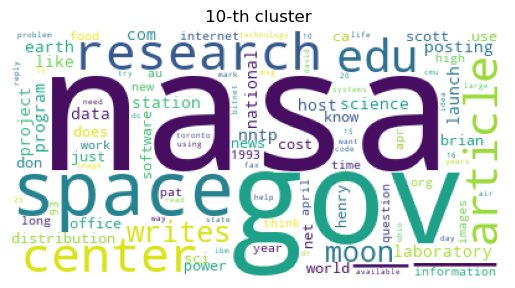

In [18]:
cl = 10
coords = kmeans.cluster_centers_[cl] 
wordcloud = WordCloud(background_color='white', stopwords = STOPWORDS, max_words=100).generate_from_frequencies(dict(zip(lsa_vocab,np.abs(coords))))

plt.figure()
plt.imshow(wordcloud)
plt.axis("off")
plt.title(f"{cl}-th cluster")
plt.show()

coords = kmeans.cluster_centers_[cl] @ svd.components_
wordcloud = WordCloud(background_color='white', stopwords = STOPWORDS, max_words=100).generate_from_frequencies(dict(zip(vocab,np.abs(coords))))

plt.figure()
plt.imshow(wordcloud)
plt.axis("off")
plt.title(f"{cl}-th cluster")
plt.show()

In [19]:
purity = np.zeros(kmeans.n_clusters)
for cluster in range(kmeans.n_clusters):
    cluster_mask = (kmeans.labels_ == cluster)
    y_counts = np.bincount( Y[cluster_mask])
    gt = np.argmax(y_counts)
    p  = y_counts[gt] / y_counts.sum() # is purity expressed in counts of as probas?
    print(f"Cluster {cluster}, purity={p:1.2}: label {gt} {newsgroups_train.target_names[gt]}")

    purity[cluster] = p

print(f"Overall purity = {purity.sum() / purity.size}")

Cluster 0, purity=0.55: label 14 sci.space
Cluster 1, purity=0.33: label 0 alt.atheism
Cluster 2, purity=0.58: label 7 rec.autos
Cluster 3, purity=0.13: label 8 rec.motorcycles
Cluster 4, purity=0.18: label 6 misc.forsale
Cluster 5, purity=0.17: label 10 rec.sport.hockey
Cluster 6, purity=0.15: label 5 comp.windows.x
Cluster 7, purity=0.22: label 16 talk.politics.guns
Cluster 8, purity=0.94: label 13 sci.med
Cluster 9, purity=0.6: label 10 rec.sport.hockey
Cluster 10, purity=0.48: label 14 sci.space
Cluster 11, purity=0.26: label 18 talk.politics.misc
Cluster 12, purity=0.12: label 1 comp.graphics
Cluster 13, purity=0.61: label 15 soc.religion.christian
Cluster 14, purity=0.98: label 17 talk.politics.mideast
Cluster 15, purity=0.55: label 3 comp.sys.ibm.pc.hardware
Cluster 16, purity=0.95: label 11 sci.crypt
Cluster 17, purity=0.53: label 2 comp.os.ms-windows.misc
Cluster 18, purity=1.0: label 17 talk.politics.mideast
Cluster 19, purity=0.15: label 9 rec.sport.baseball
Overall purity =

In [20]:
# t-SNE from the U matrix computed by LSA
from sklearn.manifold import TSNE
tsne = TSNE(n_components=2, init='pca',max_iter=5000, verbose=2)
tsne_mat = tsne.fit_transform(lsa_vectors)

[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 11314 samples in 0.000s...
[t-SNE] Computed neighbors for 11314 samples in 0.090s...
[t-SNE] Computed conditional probabilities for sample 1000 / 11314
[t-SNE] Computed conditional probabilities for sample 2000 / 11314
[t-SNE] Computed conditional probabilities for sample 3000 / 11314
[t-SNE] Computed conditional probabilities for sample 4000 / 11314
[t-SNE] Computed conditional probabilities for sample 5000 / 11314
[t-SNE] Computed conditional probabilities for sample 6000 / 11314
[t-SNE] Computed conditional probabilities for sample 7000 / 11314
[t-SNE] Computed conditional probabilities for sample 8000 / 11314
[t-SNE] Computed conditional probabilities for sample 9000 / 11314
[t-SNE] Computed conditional probabilities for sample 10000 / 11314
[t-SNE] Computed conditional probabilities for sample 11000 / 11314
[t-SNE] Computed conditional probabilities for sample 11314 / 11314
[t-SNE] Mean sigma: 0.069988
[t-SNE] Computed cond

/var/folders/hr/c9xk46kd0t3c2nlgs6zkg2_h0000gn/T/ipykernel_46385/3011881098.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab20", n_clusters)


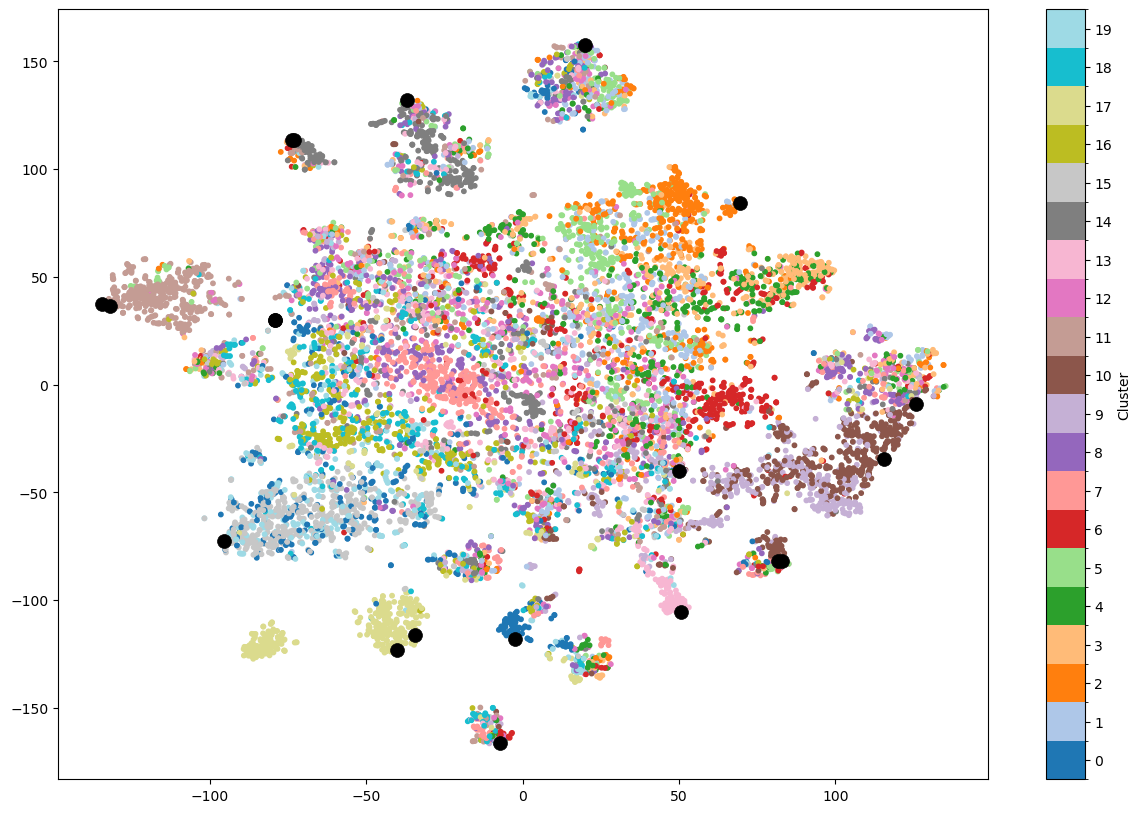

In [21]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as colors
import numpy as np

NN2cluster = np.argmax(np.abs(lsa_vectors), axis=0) # get idx of documents with highest value for each word / theme

n_clusters = 20

cmap = cm.get_cmap("tab20", n_clusters)
norm = colors.BoundaryNorm(
    boundaries=np.arange(-0.5, n_clusters + 0.5, 1),
    ncolors=n_clusters
)

plt.figure(figsize=(15, 10))

sc = plt.scatter(
    tsne_mat[:, 0],
    tsne_mat[:, 1],
    c=Y,
    cmap=cmap,
    norm=norm,
    s=10
)

plt.scatter(
    tsne_mat[NN2cluster, 0],
    tsne_mat[NN2cluster, 1],
    c="black",
    s=100,
    linewidths=0.5
)

cbar = plt.colorbar(sc, ticks=
                    range(n_clusters)
                    )
cbar.set_label("Cluster")

plt.show()

# TODO:  check, result looks bad (see lecture slides!)

In [22]:
newsgroups_train.target_names[11]

'sci.crypt'

# 3) Latent Dirichlet Allocation (LDA)

Perform the same experiments with LDA:
- LDA
https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.LatentDirichletAllocation.html


**Start with a CountVectorizer**

In [23]:
from nltk.tokenize import RegexpTokenizer
from sklearn.feature_extraction.text import CountVectorizer

# Initialize regex tokenizer
tokenizer = RegexpTokenizer(r'\w+')

# Vectorize document using TF-IDF
vectorizer = CountVectorizer(lowercase=True,
                        stop_words='english',
                        ngram_range = (1,1),
                        tokenizer = tokenizer.tokenize, max_df=0.95, min_df=2, max_features=1000)

vectors = vectorizer.fit_transform(newsgroups_train.data)
print(vectors.shape)
print(vectors.nnz / float(vectors.shape[0]))

/Users/vlad/miniconda3/envs/rital/lib/python3.10/site-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


(11314, 1000)
48.02527841612162


In [24]:
from sklearn.decomposition import LatentDirichletAllocation

lda = LatentDirichletAllocation(n_components=20)
lda.fit(vectors)

,n_components,20
,doc_topic_prior,None
,topic_word_prior,None
,learning_method,'batch'
,learning_decay,0.7
,learning_offset,10.0
,max_iter,10
,batch_size,128
,evaluate_every,-1
,total_samples,1000000.0
,perp_tol,0.1


## LDA-viz

In [48]:
# pip install install pyldavis
from __future__ import print_function

import pyLDAvis
pyLDAvis.enable_notebook()

X = vectors 

doc_topic_dists = lda.transform(X)

topic_word_dists = lda.components_ / lda.components_.sum(axis=1)[:, np.newaxis]

doc_lengths = X.sum(axis=1).A1

vocab = vectorizer.get_feature_names_out()

term_frequency = X.sum(axis=0).A1

vis_data = pyLDAvis.prepare(
    topic_word_dists,
    doc_topic_dists,
    doc_lengths,
    vocab,
    term_frequency
)

pyLDAvis.display(vis_data)

# Performances evaluation

**Compare the different approaches wrt three quantitative metrics.**

# TODO!